print("Task 2: Credit Risk Prediction")
print("This project predicts whether a loan applicant is likely to default on a loan using machine learning.")

In [1]:
import os

print(os.listdir("Downloads"))

['duplicati-2.2.0.1_stable_2025-11-09-osx-arm64-gui.dmg', 'IMG_3112.HEIC', 'android-studio-2024.3.2.14-mac_arm (1).dmg', 'Blue and Gray Simple Professional CV Resume (1).pdf', 'WhatsApp Image 2025-10-08 at 09.32.13.jpeg', 'Research Paper.docx', 'log book yasir (1).docx', 'apdp report .docx (1).pdf', 'IMG_3104.HEIC', 'Visual Studio Code.app', 'LO1_SmartClinic_Presentation.pptx', 'mo SYSTEM ANALYSIS.docx', 'IMG_3108.HEIC', 'eRM1F-xJQO2pmO-oWqwVdg_b018ed73bc4f46478f485102e48296f1_Data-Analytics-Certificate-glossary.docx', 'Doc10 (1).docx', 'yasir_portfolio.html', '_YASIR KHAN presentation.pptx', '.DS_Store', 'IMG_3109.HEIC', 'yasir_portfolio_v3.html', 'WhatsApp Image 2025-10-08 at 09.32.12 (1).jpeg', 'IMG_1443.PNG', 'LO4 report.docx', 'iloveimg-converted (1).zip', 'IMG_1441.PNG', 'pythone', 'bps 2 report.docx', 'Black and Orange Modern Videographer Portfolio Presentation (1).pptx', 'Purple and Dark Black Gradient Modern Video Production Company Presentation.pptx', 'Yasir Khan Computing_pa

print("""
Objective:
The objective of this project is to predict whether a loan applicant is likely to default on a loan.

The project aims to:
1. Load and understand the Loan Prediction dataset.
2. Handle missing values.
3. Visualize important features.
4. Train classification models.
5. Evaluate model performance.
""")

In [2]:
import pandas as pd

df = pd.read_csv("Downloads/train.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(614, 13)


In [4]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

print("Missing Values Removed")

Missing Values Removed


In [7]:
print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


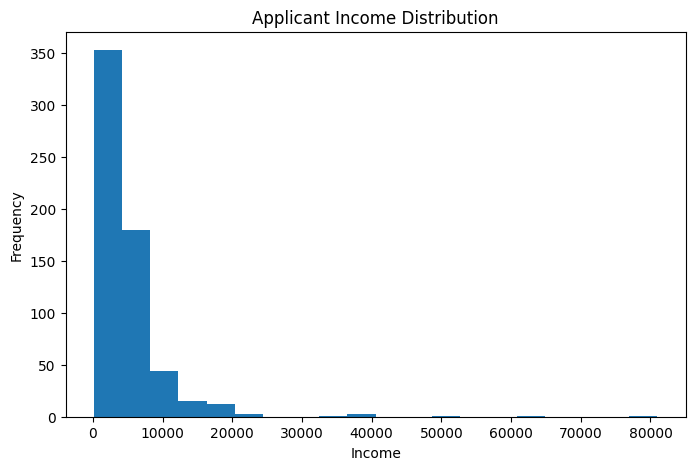

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['ApplicantIncome'], bins=20)
plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

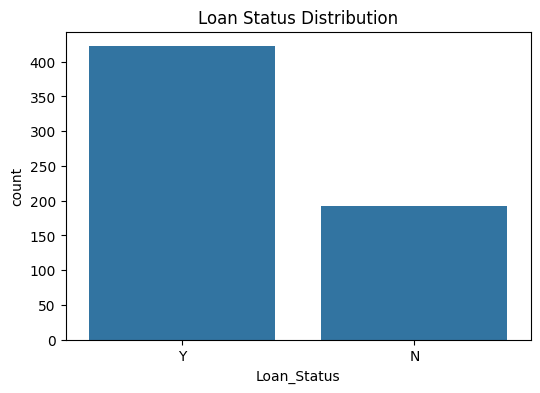

In [9]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

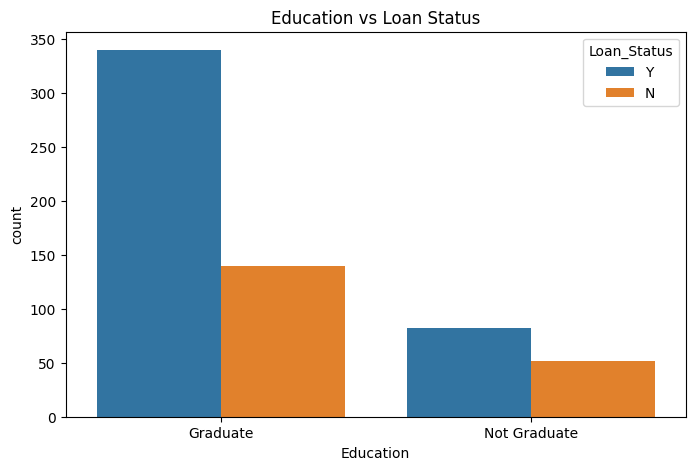

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education vs Loan Status")
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("Encoding Completed")

Encoding Completed


In [12]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print(X.shape)
print(y.shape)

(614, 12)
(614,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (491, 12)
Testing Data: (123, 12)


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

print("Model Trained Successfully Without Warning")

Model Trained Successfully Without Warning


In [16]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7886178861788617


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18 25]
 [ 1 79]]


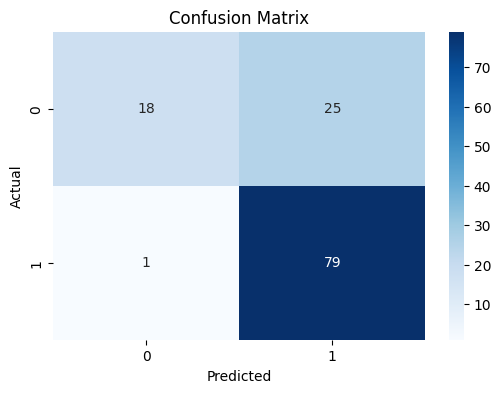

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
# Conclusion

The Credit Risk Prediction model was developed using Logistic Regression.

The dataset was cleaned by handling missing values and converting categorical variables into numerical values using Label Encoding.

Exploratory Data Analysis (EDA) was performed using histograms and count plots to understand the dataset.

The Logistic Regression model achieved an accuracy of approximately 78.86%, indicating a good ability to predict loan approval status.

The confusion matrix was used to evaluate the classification performance of the model.

This project demonstrates the use of machine learning techniques for credit risk assessment and loan approval prediction.

SyntaxError: invalid syntax (2367766681.py, line 3)

In [21]:
print("""
CONCLUSION

The Credit Risk Prediction model was developed using Logistic Regression.

The dataset was cleaned by handling missing values and converting categorical variables into numerical values using Label Encoding.

Exploratory Data Analysis (EDA) was performed using histograms and count plots to understand the dataset.

The Logistic Regression model achieved an accuracy of approximately 78.86%, indicating a good ability to predict loan approval status.

The confusion matrix was used to evaluate the classification performance of the model.

This project demonstrates the use of machine learning techniques for credit risk assessment and loan approval prediction.
""")


CONCLUSION

The Credit Risk Prediction model was developed using Logistic Regression.

The dataset was cleaned by handling missing values and converting categorical variables into numerical values using Label Encoding.

Exploratory Data Analysis (EDA) was performed using histograms and count plots to understand the dataset.

The Logistic Regression model achieved an accuracy of approximately 78.86%, indicating a good ability to predict loan approval status.

The confusion matrix was used to evaluate the classification performance of the model.

This project demonstrates the use of machine learning techniques for credit risk assessment and loan approval prediction.

